In [1]:
from rubin_sim import maf
from rubin_sim.data import get_data_dir

try:
    from rubin_sim.data import get_baseline
except ImportError:
    from rubin_scheduler.data import get_baseline
import rubin_sim
from rubin_sim import data
from rubin_sim.data import get_baseline
import healpy as hp
import numpy as np
import sqlite3
from astropy.coordinates import SkyCoord
import astropy.units as u
import datashader as ds
import matplotlib.pyplot as plt
import matplotlib as mpl
from datashader.mpl_ext import dsshow
import pandas as pd
import galsim
import matplotlib.lines as mlines

# # set up the outdir
# outdir = 'test'
# import os
# os.makedirs(outdir, exist_ok=True)

opsim_fname = "/Users/msredden/Documents/DESC/DifferentialCR/db files/baseline_v5.1.0_10yrs.db" #get_baseline() "
print(opsim_fname)

con = sqlite3.connect(opsim_fname)
cur = con.cursor()

cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cur.fetchall()
print("Tables:", tables)

table_name = 'observations'  # replace with the actual table name
cur.execute(f"PRAGMA table_info({table_name});")
columns = cur.fetchall()
column_names = [col[1] for col in columns]
print("Column Names:", column_names)

/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/msredden/Documents/DESC/DifferentialCR/db files/baseline_v5.1.0_10yrs.db
Tables: [('observations',), ('info',), ('events',)]
Column Names: ['observationId', 'fieldRA', 'fieldDec', 'observationStartMJD', 'flush_by_mjd', 'visitExposureTime', 'band', 'filter', 'rotSkyPos', 'rotSkyPos_desired', 'numExposures', 'airmass', 'seeingFwhm500', 'seeingFwhmEff', 'seeingFwhmGeom', 'skyBrightness', 'night', 'slewTime', 'visitTime', 'slewDistance', 'fiveSigmaDepth', 'altitude', 'azimuth', 'paraAngle', 'pseudoParaAngle', 'cloud', 'moonAlt', 'sunAlt', 'scheduler_note', 'target_name', 'target_id', 'observationStartLST', 'rotTelPos', 'rotTelPos_backup', 'moonAz', 'sunAz', 'sunRA', 'sunDec', 'moonRA', 'moonDec', 'moonDistance', 'solarElong', 'moonPhase', 'cummTelAz', 'observation_reason', 'science_program', 'cloud_extinction']


In [36]:
nside = 128

# example4_bundles = {
#     "airmass": maf.MetricBundle(
#         metric=maf.PercentileMetric(col="airmass", percentile = 50),
#         slicer=maf.slicers.HealpixSlicer(nside=nside),
#         constraint="filter = 'i'",
#         plot_dict={"color": "g"},
#         # run_name=run_name,
#     ),
#     "cosmology": maf.MetricBundle(
#         metric=maf.metrics.ExgalM5WithCuts(lsst_filter="i", extinction_cut=0.2,
#                                     depth_cut=25.9, n_filters=6,
#                                     ),
#         slicer=maf.slicers.HealpixSlicer(nside=nside),
#         constraint="scheduler_note not like '%DD%'",
#         plot_dict={"color": "r"},
#         # run_name=run_name,
#     ),
# }

# example_bundle = {"parallactic angle": maf.MetricBundle(
#         metric=maf.CountMetric(col="PA"),
#         slicer=maf.OneDSlicer(slice_col_name="PA", bin_min=-360, bin_max=360, bin_size=2),
#         constraint="not (scheduler_note = 'twilight_near_sun, 0' or scheduler_note = 'twilight_near_sun, 1' or scheduler_note = 'twilight_near_sun, 2' or scheduler_note = 'twilight_near_sun, 3')" \
#         "and (fieldRA - 53.5 < 0.1 or fieldRA - 53.5 > 359.9) and (fieldDec - (-28) < 0.1 or fieldDec - (-28) > -0.1)",
#         plot_dict={'fontsize': 14,
#                   'labelsize': 20,
#                   'figsize': (5.5, 2.55),
#                   'alpha': 1,
#                    'x_min': -180,
#                    'x_max': 180,
#                   'xlabel': 'Parallactic Angle',
#                   'ylabel':'Frequency',
#                   'title': 'OpSim visits: baseline_v5.1.0_10yrs.db'},
#         # run_name=run_name,
#     )}

example_bundle = {"parallactic angle": maf.MetricBundle(
        metric=maf.CountMetric(col="PA"),
        slicer=maf.OneDSlicer(slice_col_name="PA", bin_min=-180, bin_max=180, bin_size=2),
        constraint="",
        plot_dict={'fontsize': 14,
                  'labelsize': 20,
                  'figsize': (5.5, 2.55),
                  'alpha': 1,
                   'x_min': -180,
                   'x_max': 180,
                  'xlabel': 'Parallactic Angle',
                  'ylabel':'Frequency',
                  'title': 'OpSim visits: baseline_v5.1.0_10yrs.db'},
        # run_name=run_name,
    )}


example_bg = maf.MetricBundleGroup(example_bundle, opsim_fname, out_dir='scrap')
example_bg.run_all()

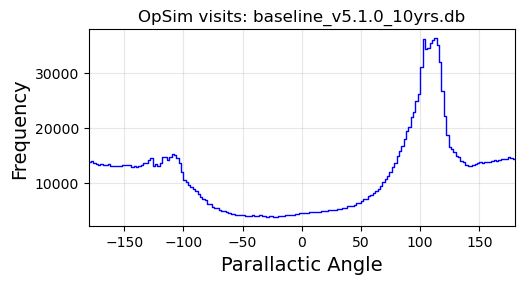

In [37]:
example_bg.plot_all(closefigs=False)

In [45]:
counts = example_bundle['parallactic angle'].metric_values
slice_points = example_bundle['parallactic angle'].slicer.slice_points
print(counts)

[13825.0 13974.0 13683.0 13398.0 13215.0 13383.0 13189.0 13201.0 13466.0
 13133.0 13153.0 13166.0 13090.0 13077.0 13205.0 13350.0 13294.0 13202.0
 12912.0 13007.0 12978.0 13120.0 13200.0 13536.0 13678.0 14158.0 14540.0
 13125.0 13365.0 13078.0 13641.0 14628.0 14697.0 14230.0 14782.0 15247.0
 15021.0 14556.0 13710.0 12029.0 10611.0 10099.0 9690.0 9232.0 8948.0
 8597.0 8061.0 7527.0 7166.0 6887.0 6240.0 6233.0 5717.0 5414.0 5386.0
 5099.0 4905.0 4832.0 4662.0 4568.0 4430.0 4310.0 4252.0 4169.0 4121.0
 4089.0 4025.0 4031.0 4029.0 4144.0 4006.0 3986.0 4103.0 3905.0 3983.0
 3849.0 3945.0 4079.0 3852.0 3873.0 4011.0 3980.0 4039.0 4105.0 4101.0
 4231.0 4158.0 4431.0 4425.0 4461.0 4453.0 4589.0 4590.0 4671.0 4672.0
 4789.0 4720.0 4728.0 4816.0 4914.0 4922.0 5073.0 4998.0 5049.0 5060.0
 5210.0 5339.0 5367.0 5538.0 5806.0 5773.0 5898.0 6066.0 6373.0 6387.0
 6766.0 7054.0 7125.0 7670.0 7893.0 8192.0 8572.0 8891.0 9400.0 10113.0
 10765.0 11330.0 12065.0 12869.0 13692.0 14853.0 15879.0 16647.0 1793

Mean of sin(2q): -0.041761
Mean of cos(2q): -0.159267


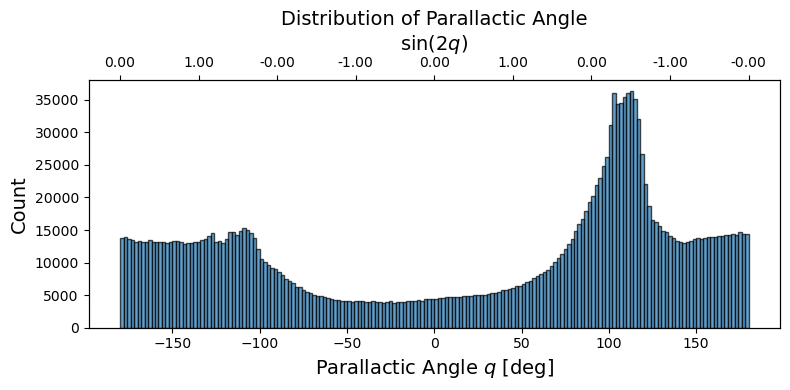

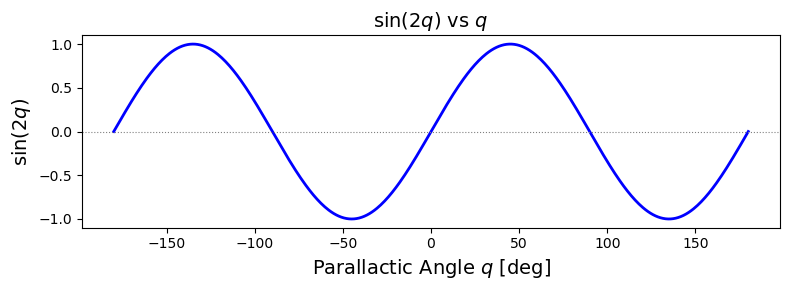

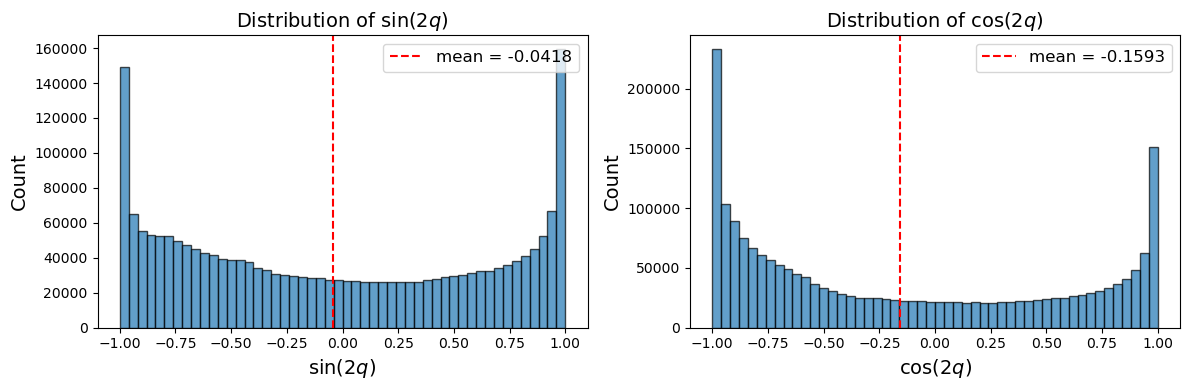

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Bin centers and widths from slice_points (bin edges)
bin_edges = slice_points['bins']
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths = bin_edges[1:] - bin_edges[:-1]

# Build a fake dataset: repeat each bin center by its count,
# then add uniform jitter within each bin for smoothness
c = np.asarray(counts.flatten(), dtype=int)
rng = np.random.default_rng(42)
q_samples = np.concatenate([
    rng.uniform(low=bin_edges[i], high=bin_edges[i+1], size=c[i])
    for i in range(len(c))
])

# Convert to radians and compute trig functions
q_rad = np.deg2rad(q_samples)
sin2q_samples = np.sin(2 * q_rad)
cos2q_samples = np.cos(2 * q_rad)

# Means
mean_sin2q = np.mean(sin2q_samples)
mean_cos2q = np.mean(cos2q_samples)

print(f"Mean of sin(2q): {mean_sin2q:.6f}")
print(f"Mean of cos(2q): {mean_cos2q:.6f}")

# --- Figure 1: PA histogram with secondary x-axis for sin(2q) ---
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.hist(q_samples, bins=bin_edges, edgecolor='k', alpha=0.7)
ax1.set_xlabel(r'Parallactic Angle $q$ [deg]', fontsize=14)
ax1.set_ylabel('Count', fontsize=14)
ax1.set_title('Distribution of Parallactic Angle', fontsize=14)

# Secondary x-axis: show sin(2q) at each q tick
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
q_ticks = np.arange(-180, 181, 45)
ax2.set_xticks(q_ticks)
ax2.set_xticklabels([f'{np.sin(2*np.deg2rad(t)):.2f}' for t in q_ticks])
ax2.set_xlabel(r'$\sin(2q)$', fontsize=14)
fig1.tight_layout()
plt.show()

# --- Figure 2: sin(2q) vs q curve ---
q_fine = np.linspace(-180, 180, 500)
fig2, ax3 = plt.subplots(figsize=(8, 3))
ax3.plot(q_fine, np.sin(2 * np.deg2rad(q_fine)), 'b-', lw=2)
ax3.axhline(0, color='gray', ls=':', lw=0.8)
ax3.set_xlabel(r'Parallactic Angle $q$ [deg]', fontsize=14)
ax3.set_ylabel(r'$\sin(2q)$', fontsize=14)
ax3.set_title(r'$\sin(2q)$ vs $q$', fontsize=14)
fig2.tight_layout()
plt.show()

# --- Figure 3: Distributions of sin(2q) and cos(2q) ---
fig3, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(sin2q_samples, bins=50, edgecolor='k', alpha=0.7)
ax.axvline(mean_sin2q, color='r', ls='--', label=f'mean = {mean_sin2q:.4f}')
ax.set_xlabel(r'$\sin(2q)$', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_title(r'Distribution of $\sin(2q)$', fontsize=14)
ax.legend(fontsize=12)

ax = axes[1]
ax.hist(cos2q_samples, bins=50, edgecolor='k', alpha=0.7)
ax.axvline(mean_cos2q, color='r', ls='--', label=f'mean = {mean_cos2q:.4f}')
ax.set_xlabel(r'$\cos(2q)$', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_title(r'Distribution of $\cos(2q)$', fontsize=14)
ax.legend(fontsize=12)

fig3.tight_layout()
plt.show()

In [12]:
# Playing with the DcrPrecisionMetric

nside = 128

example_bundle = {"DcrPrecisionMetric": maf.MetricBundle(
        metric=maf.DcrPrecisionMetric(),
        slicer=maf.slicers.HealpixSlicer(nside=nside),
        constraint="band = 'g'",
        plot_dict = {  "percentile_clip": 95, 'extend': 'both', 'cbar_orientation': 'vertical',} #"percentile_clip": 95
        ),
        "observation count": maf.MetricBundle(
        metric=maf.CountMetric(col = 'filter'),
        slicer=maf.slicers.HealpixSlicer(nside=nside),
        constraint="band = 'g'",
        plot_dict = { "percentile_clip" : 95, 'cbar_orientation': 'vertical',} #"percentile_clip": 95
    )}


example_bg = maf.MetricBundleGroup(example_bundle, opsim_fname, out_dir='scrap')
example_bg.run_all()

Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes


/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/rubin_sim/maf/stackers/base_stacker.py:139: UserWarning: Warning - column zenithDistance already present in sim_data, may be overwritten (depending on stacker).
  warnings.warn(


/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/rubin_sim/maf/utils/maf_utils.py:153: UserWarning: Optimal bin calculation tried to make 2420 bins, returning 200
  warnings.warn(
/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/rubin_sim/maf/utils/maf_utils.py:153: UserWarning: Optimal bin calculation tried to make 1886 bins, returning 200
  warnings.warn(


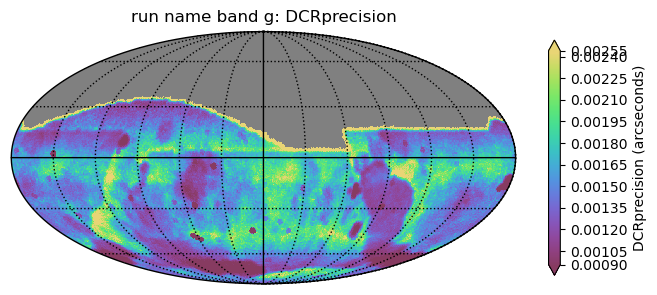

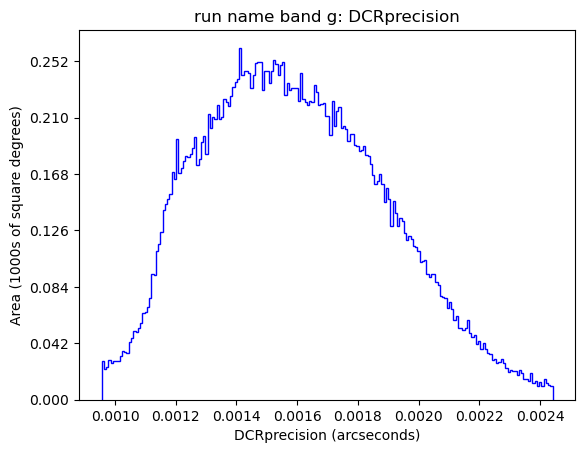

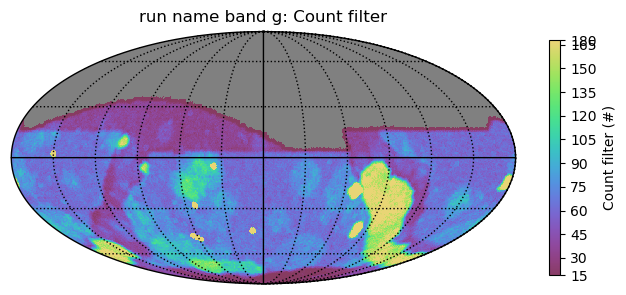

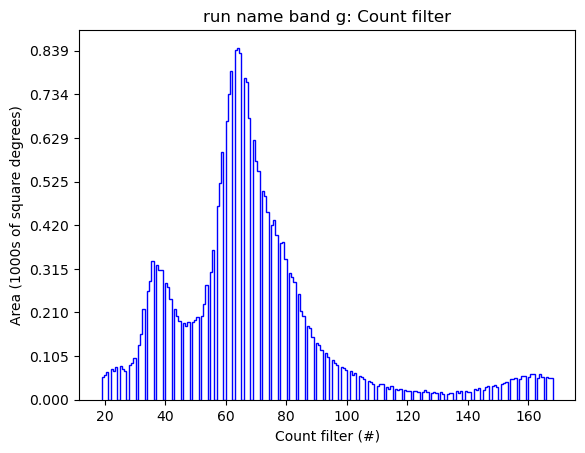

In [13]:
example_bg.plot_all(closefigs=False)

In [2]:
# Playing with the ParallaxDcrDegenMetric

nside = 128

example_bundle = {"ParallaxDcrDegenMetric": maf.MetricBundle(
        metric=maf.ParallaxDcrDegenMetric(),
        slicer=maf.slicers.HealpixSlicer(nside=nside),
        constraint="band = 'g'",
        plot_dict = { "percentile_clip": 90, 'extend': 'both', 'cbar_orientation': 'vertical',} #"percentile_clip": 50
    )}


example_bg = maf.MetricBundleGroup(example_bundle, opsim_fname, out_dir='scrap')
example_bg.run_all()

Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes


/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 154102 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 154102 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


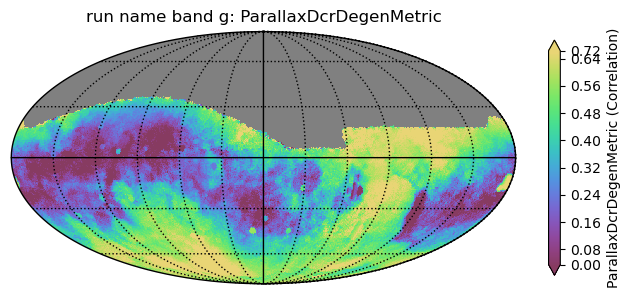

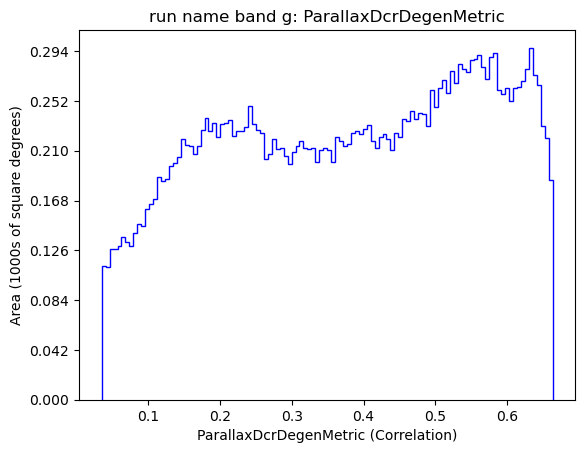

In [3]:
example_bg.plot_all(closefigs=False)

In [6]:
nside = 128
opsim_fname = get_baseline()

example5_bundles = {
    "airmass": maf.MetricBundle(
        metric=maf.PercentileMetric(col="airmass", percentile = 50),
        slicer=maf.slicers.HealpixSlicer(nside=nside),
        constraint="filter = 'i'",
        plot_dict={"color": "g"},
        # run_name=run_name,
    ),
    "parallacticAngle": maf.MetricBundle(
        metric=maf.PercentileMetric(col="PA", percentile = 50),
        slicer=maf.slicers.HealpixSlicer(nside=nside),
        constraint="filter = 'i'",
        plot_dict={"color": "g"},
        # run_name=run_name,
    ),
}

example5_bg = maf.MetricBundleGroup(example5_bundles, opsim_fname, out_dir='scrap')
example5_bg.run_all()


Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes


/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/rubin_sim/maf/utils/maf_utils.py:153: UserWarning: Optimal bin calculation tried to make 255 bins, returning 200
  warnings.warn(


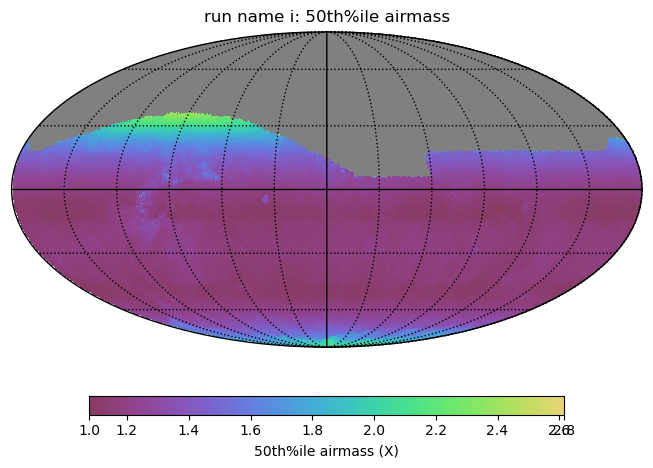

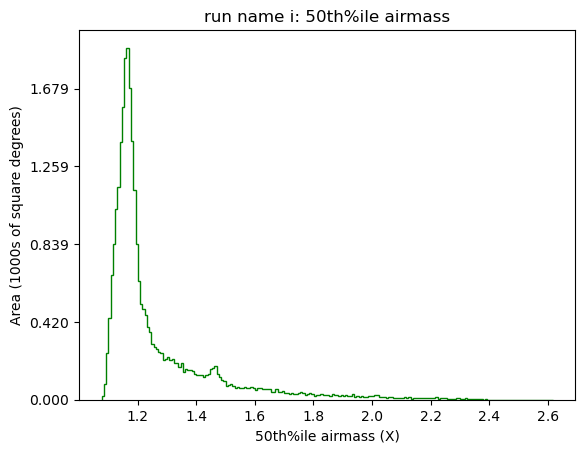

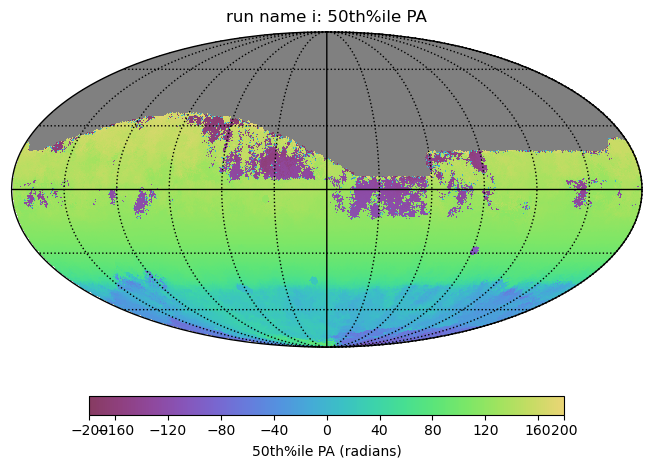

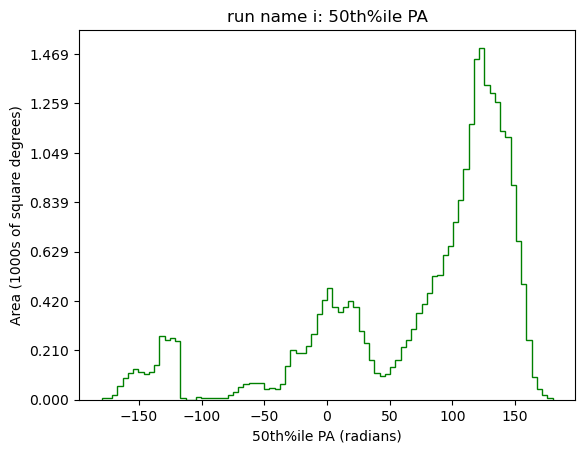

In [7]:

example5_bg.plot_all(closefigs = False)

/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 11697 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 11697 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utcut1" yielded 11697 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "epv00" yielded 4229 of "warning: date outsidethe range 1900-2100 AD"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


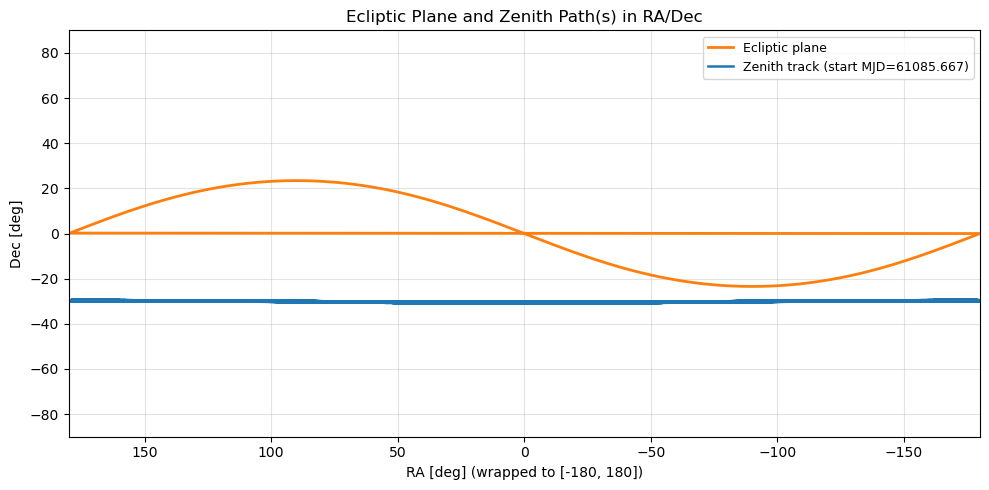

In [7]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import AltAz, EarthLocation, GeocentricTrueEcliptic, SkyCoord
from astropy.time import Time

# -----------------------
# PLACEHOLDERS TO UPDATE
# -----------------------
# Observatory coordinates (replace with your site values)
OBS_LAT_DEG = -30.2444   # latitude in degrees (placeholder)
OBS_LON_DEG = -70.7494   # longitude in degrees (placeholder)
OBS_HEIGHT_M = 2663.0    # elevation in meters (placeholder)

# Coordinates of the observatory:
OBS_LAT_DEG = -30.244633 #-30:14:40.68
OBS_LON_DEG = -70.749417 #-70:44:57.90
OBS_HEIGHT_M = 2647 


# Observation run start times in MJD (replace with your run starts)
RUN_START_MJDS = [61085.6667]  # placeholders

# Duration and cadence for each run track
RUN_DURATION_HR = 1000000.0
SAMPLES_PER_RUN = 12000

# Ecliptic plane sampling
ecl_lon = np.linspace(0, 360, 721) * u.deg
ecl_lat = np.zeros_like(ecl_lon.value) * u.deg
ecliptic = SkyCoord(
    lon=ecl_lon,
    lat=ecl_lat,
    frame=GeocentricTrueEcliptic(equinox=Time("J2000")),
)
ecliptic_icrs = ecliptic.transform_to("icrs")

# Observatory location
site = EarthLocation(
    lat=OBS_LAT_DEG * u.deg,
    lon=OBS_LON_DEG * u.deg,
    height=OBS_HEIGHT_M * u.m,
)

# Build zenith tracks in ICRS RA/Dec
zenith_tracks = []
for mjd0 in RUN_START_MJDS:
    dt_hr = np.linspace(0.0, RUN_DURATION_HR, SAMPLES_PER_RUN)
    times = Time(mjd0, format="mjd", scale="utc") + dt_hr * u.hour

    zen_altaz = SkyCoord(
        alt=np.full_like(dt_hr, 90.0) * u.deg,
        az=np.zeros_like(dt_hr) * u.deg,
        frame=AltAz(obstime=times, location=site),
    )
    zen_icrs = zen_altaz.transform_to("icrs")
    zenith_tracks.append((mjd0, zen_icrs.ra.deg, zen_icrs.dec.deg))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    ecliptic_icrs.ra.wrap_at(180 * u.deg).deg,
    ecliptic_icrs.dec.deg,
    color="tab:orange",
    lw=2,
    label="Ecliptic plane",
)

for mjd0, ra_deg, dec_deg in zenith_tracks:
    ax.plot(
        Angle := ((ra_deg + 180) % 360 - 180),
        dec_deg,
        lw=1.8,
        label=f"Zenith track (start MJD={mjd0:.3f})",
    )

ax.set_xlabel("RA [deg] (wrapped to [-180, 180])")
ax.set_ylabel("Dec [deg]")
ax.set_title("Ecliptic Plane and Zenith Path(s) in RA/Dec")
ax.grid(True, alpha=0.35)
ax.set_xlim(180, -180)
ax.set_ylim(-90, 90)
ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()